<a href="https://colab.research.google.com/github/JustinEight/fruit-classification-app/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phân loại trái cây: Đu đủ / Hồng / Bưởi
**CNN tự xây vs Transfer Learning (MobileNetV2)**

> Chạy trên Google Colab — Runtime → Change runtime type → **GPU (T4)**

## Giai đoạn 0 — Cài đặt thư viện & kiểm tra GPU

In [ ]:
!pip install -q kaggle gradio
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os, shutil, random
from pathlib import Path
from PIL import Image

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

ERROR: Operation cancelled by user
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Giai đoạn 1 — Tải & tổ chức dữ liệu từ Kaggle Fruits-360

In [ ]:
# Upload file kaggle.json trước khi chạy ô này
# Menu Colab: Files (icon thư mục bên trái) → Upload → chọn kaggle.json
from google.colab import files
uploaded = files.upload()  # chọn kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d moltean/fruits
!unzip -q fruits.zip -d fruits_full
!ls fruits_full/fruits-360_dataset/fruits-360/Training/ | grep -iE 'papaya|kaki|pomelo'

Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 6.52G/6.52G [01:29<00:00, 78.0MB/s]

ls: cannot access 'fruits_full/fruits-360_dataset/fruits-360/Training/': No such file or directory


In [ ]:
# Tên thư mục trong Fruits-360 → tên lớp của chúng ta
LABEL_MAP = {
    'Papaya':         'papaya',
    'Kaki':           'persimmon',
    'Pomelo Sweetie': 'pomelo',
}

SRC_TRAIN = Path('fruits_full/fruits-360_dataset/fruits-360/Training')
SRC_TEST  = Path('fruits_full/fruits-360_dataset/fruits-360/Test')
DST_ROOT  = Path('data')

def copy_class(src_split, dst_split, src_name, dst_name):
    src = src_split / src_name
    dst = DST_ROOT / dst_split / dst_name
    dst.mkdir(parents=True, exist_ok=True)
    for f in src.glob('*.jpg'):
        shutil.copy(f, dst / f.name)
    print(f'  {dst_split}/{dst_name}: {len(list(dst.glob("*.jpg")))} ảnh')

print('Sao chép dữ liệu...')
for src_name, dst_name in LABEL_MAP.items():
    copy_class(SRC_TRAIN, 'train', src_name, dst_name)
    copy_class(SRC_TEST,  'test',  src_name, dst_name)
print('Hoàn tất!')

Sao chép dữ liệu...
  train/papaya: 0 ảnh
  test/papaya: 0 ảnh
  train/persimmon: 0 ảnh
  test/persimmon: 0 ảnh
  train/pomelo: 0 ảnh
  test/pomelo: 0 ảnh
Hoàn tất!


## Giai đoạn 2 — EDA & Tiền xử lý

Đã tạo thư mục report/ và models/


/tmp/ipykernel_780/3876278368.py:17: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max(counts[split].values()) * 1.15)


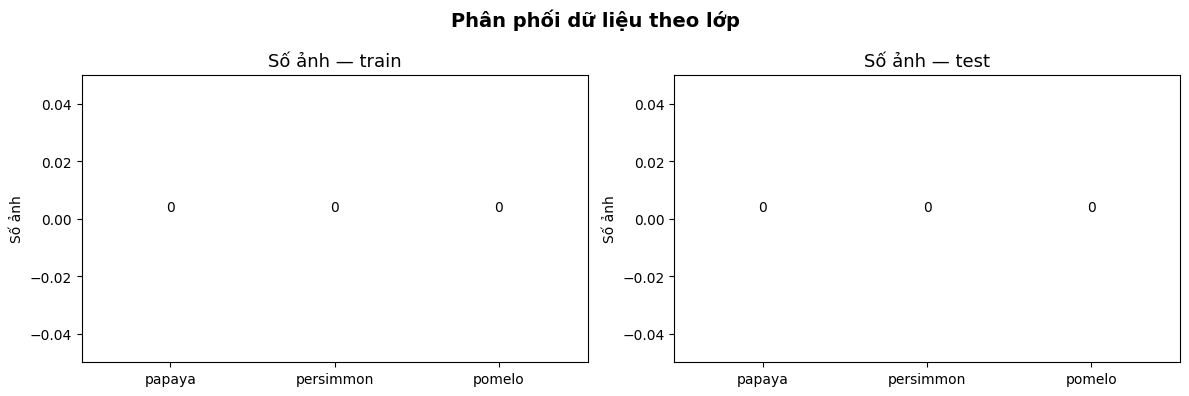

Tổng: {'train': 0, 'test': 0}


In [ ]:
import os
os.makedirs('report', exist_ok=True)
os.makedirs('models', exist_ok=True)
print("Đã tạo thư mục report/ và models/")
CLASSES = ['papaya', 'persimmon', 'pomelo']
SPLITS  = ['train', 'test']

counts = {s: {c: len(list((DST_ROOT / s / c).glob('*.jpg'))) for c in CLASSES} for s in SPLITS}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#FF6B6B', '#FFD93D', '#6BCB77']
for ax, split in zip(axes, SPLITS):
    bars = ax.bar(CLASSES, [counts[split][c] for c in CLASSES], color=colors)
    ax.bar_label(bars, padding=3)
    ax.set_title(f'Số ảnh — {split}', fontsize=13)
    ax.set_ylabel('Số ảnh')
    ax.set_ylim(0, max(counts[split].values()) * 1.15)
plt.suptitle('Phân phối dữ liệu theo lớp', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('report/fig1_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tổng:', {s: sum(counts[s].values()) for s in SPLITS})

In [ ]:
import shutil, os, random
from pathlib import Path

SRC_TRAIN = Path('fruits_full/fruits-360_100x100/fruits-360/Training')
SRC_TEST  = Path('fruits_full/fruits-360_100x100/fruits-360/Test')
DST_ROOT  = Path('data')

# Mapping đúng: tên thư mục Fruits-360 → tên lớp
LABEL_MAP = {
    'Papaya 1':       'papaya',
    'Papaya 2':       'papaya',
    'Kaki 1':         'persimmon',
    'Pomelo Sweetie 1': 'pomelo',
}

# Tạo thư mục đích
for split in ['train', 'test']:
    for cls in ['papaya', 'persimmon', 'pomelo']:
        (DST_ROOT / split / cls).mkdir(parents=True, exist_ok=True)

def copy_folder(src_dir, dst_dir):
    copied = 0
    for f in src_dir.glob('*.jpg'):
        shutil.copy(f, dst_dir / f.name)
        copied += 1
    return copied

print('Đang copy...')
for src_name, dst_name in LABEL_MAP.items():
    n_train = copy_folder(SRC_TRAIN / src_name, DST_ROOT / 'train' / dst_name)
    n_test  = copy_folder(SRC_TEST  / src_name, DST_ROOT / 'test'  / dst_name)
    print(f'  {src_name} → train:{n_train}, test:{n_test}')

print('\nKết quả cuối:')
for split in ['train', 'test']:
    for cls in ['papaya', 'persimmon', 'pomelo']:
        n = len(list((DST_ROOT / split / cls).glob('*.jpg')))
        print(f'  {split}/{cls}: {n} ảnh')


Đang copy...
  Papaya 1 → train:492, test:164
  Papaya 2 → train:725, test:240
  Kaki 1 → train:490, test:166
  Pomelo Sweetie 1 → train:450, test:153

Kết quả cuối:
  train/papaya: 1217 ảnh
  train/persimmon: 490 ảnh
  train/pomelo: 450 ảnh
  test/papaya: 404 ảnh
  test/persimmon: 166 ảnh
  test/pomelo: 153 ảnh


In [ ]:
IMG_SIZE_CNN = (128, 128)
IMG_SIZE_TL  = (224, 224)
BATCH_SIZE   = 32

# ---- Generator cho Model A (CNN 128x128) ----
aug_cnn = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    validation_split=0.15,
)
test_gen_cnn = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_cnn = aug_cnn.flow_from_directory(
    DST_ROOT / 'train', target_size=IMG_SIZE_CNN, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42)
val_cnn = aug_cnn.flow_from_directory(
    DST_ROOT / 'train', target_size=IMG_SIZE_CNN, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42)
test_cnn = test_gen_cnn.flow_from_directory(
    DST_ROOT / 'test', target_size=IMG_SIZE_CNN, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

# ---- Generator cho Model B (MobileNetV2 224x224) ----
aug_tl = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    validation_split=0.15,
)
test_gen_tl = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)

train_tl = aug_tl.flow_from_directory(
    DST_ROOT / 'train', target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42)
val_tl = aug_tl.flow_from_directory(
    DST_ROOT / 'train', target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42)
test_tl = test_gen_tl.flow_from_directory(
    DST_ROOT / 'test', target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

print('Class index:', train_cnn.class_indices)

Found 1835 images belonging to 3 classes.
Found 322 images belonging to 3 classes.
Found 723 images belonging to 3 classes.
Found 1835 images belonging to 3 classes.
Found 322 images belonging to 3 classes.
Found 723 images belonging to 3 classes.
Class index: {'papaya': 0, 'persimmon': 1, 'pomelo': 2}


## Giai đoạn 3 — Xây dựng mô hình

In [ ]:
# ---- Model A: CNN tự xây ----
def build_cnn():
    inp = tf.keras.Input(shape=(128, 128, 3))

    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)

    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)

    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)

    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    out = tf.keras.layers.Dense(3, activation='softmax')(x)

    model = tf.keras.Model(inp, out, name='CNN_custom')
    return model

model_cnn = build_cnn()
model_cnn.summary()

Model: "CNN_custom"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,963 (16.36 MB)

 Trainable params: 4,288,515 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# ---- Model B: Transfer Learning MobileNetV2 ----
def build_mobilenet():
    base = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base.trainable = False  # đóng băng toàn bộ base

    x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
    x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(3, activation='softmax')(x)

    model = tf.keras.Model(base.input, out, name='MobileNetV2_TL')
    return model

model_tl = build_mobilenet()
model_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Giai đoạn 4 — Huấn luyện

In [ ]:
os.makedirs('models', exist_ok=True)

model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_cnn = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        'models/cnn_best.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

print('=== Huấn luyện Model A (CNN) ===')
history_cnn = model_cnn.fit(
    train_cnn, validation_data=val_cnn,
    epochs=50, callbacks=callbacks_cnn, verbose=1
)

=== Huấn luyện Model A (CNN) ===
Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.8477 - loss: 2.7480
Epoch 1: val_accuracy improved from None to 0.22671, saving model to models/cnn_best.keras

Epoch 1: finished saving model to models/cnn_best.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 25s 287ms/step - accuracy: 0.9477 - loss: 0.8887 - val_accuracy: 0.2267 - val_loss: 27.3285 - learning_rate: 0.0010
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9959 - loss: 0.0266
Epoch 2: val_accuracy did not improve from 0.22671
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - accuracy: 0.9946 - loss: 0.0453 - val_accuracy: 0.2267 - val_loss: 62.2327 - learning_rate: 0.0010
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9959 - loss: 0.0284
Epoch 3: val_accuracy did not improve from 0.22671
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 187ms/step - accuracy: 0.9924 - loss: 0.0806 - val_accuracy: 0.2267 - val_loss: 35.2654 - learning_rate: 0.0010
Epoch 4/50
58/58 ━━━━━━━━━━━━━

In [ ]:
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_tl = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        'models/mobilenet_best.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
]

print('=== Huấn luyện Model B (MobileNetV2) ===')
history_tl = model_tl.fit(
    train_tl, validation_data=val_tl,
    epochs=30, callbacks=callbacks_tl, verbose=1
)

=== Huấn luyện Model B (MobileNetV2) ===
Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.4573 - loss: 1.2519
Epoch 1: val_accuracy improved from None to 0.76398, saving model to models/mobilenet_best.keras

Epoch 1: finished saving model to models/mobilenet_best.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 72s 956ms/step - accuracy: 0.5548 - loss: 1.0481 - val_accuracy: 0.7640 - val_loss: 0.6400 - learning_rate: 1.0000e-04
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.7222 - loss: 0.6806
Epoch 2: val_accuracy improved from 0.76398 to 0.90683, saving model to models/mobilenet_best.keras

Epoch 2: finished saving model to models/mobilenet_best.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 25s 440ms/step - accuracy: 0.7537 - loss: 0.6094 - val_accuracy: 0.9068 - val_loss: 0.3907 - learning_rate: 1.0000e-04
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.8388 - loss: 0.4314
Epoch 3: val_accuracy improved from 0.90683 to 0.98758, saving model to models/mobilen

## Giai đoạn 5 — Đánh giá

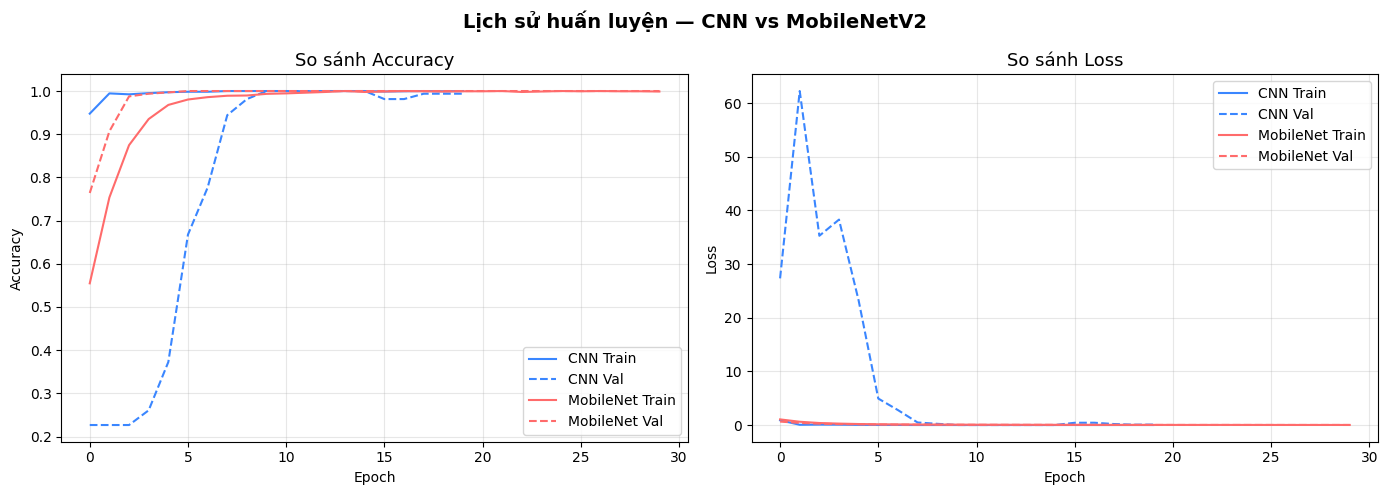

In [ ]:
def plot_history_compare(h_cnn, h_tl):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric, title in zip(
            axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
        ax.plot(h_cnn.history[metric],        label='CNN Train',        color='#3A86FF')
        ax.plot(h_cnn.history[f'val_{metric}'], label='CNN Val',         color='#3A86FF', linestyle='--')
        ax.plot(h_tl.history[metric],         label='MobileNet Train',  color='#FF6B6B')
        ax.plot(h_tl.history[f'val_{metric}'], label='MobileNet Val',   color='#FF6B6B', linestyle='--')
        ax.set_title(f'So sánh {title}', fontsize=13)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle('Lịch sử huấn luyện — CNN vs MobileNetV2', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('report/fig3_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history_compare(history_cnn, history_tl)


=== CNN Custom | Test Loss: 0.0000 | Test Accuracy: 100.00% ===

Classification Report:
              precision    recall  f1-score   support

      papaya       1.00      1.00      1.00       404
   persimmon       1.00      1.00      1.00       166
      pomelo       1.00      1.00      1.00       153

    accuracy                           1.00       723
   macro avg       1.00      1.00      1.00       723
weighted avg       1.00      1.00      1.00       723



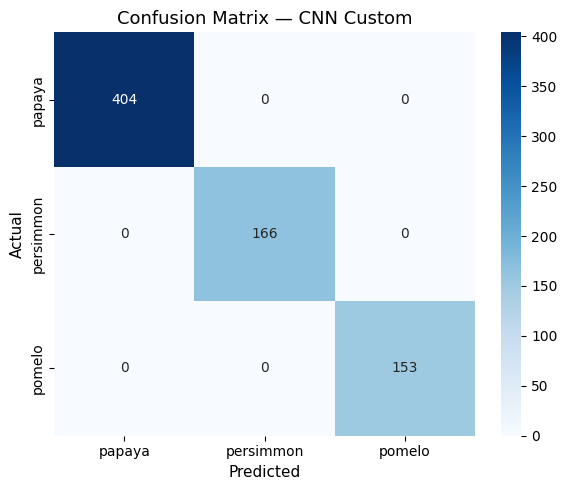


=== MobileNetV2 | Test Loss: 0.0230 | Test Accuracy: 100.00% ===

Classification Report:
              precision    recall  f1-score   support

      papaya       1.00      1.00      1.00       404
   persimmon       1.00      1.00      1.00       166
      pomelo       1.00      1.00      1.00       153

    accuracy                           1.00       723
   macro avg       1.00      1.00      1.00       723
weighted avg       1.00      1.00      1.00       723



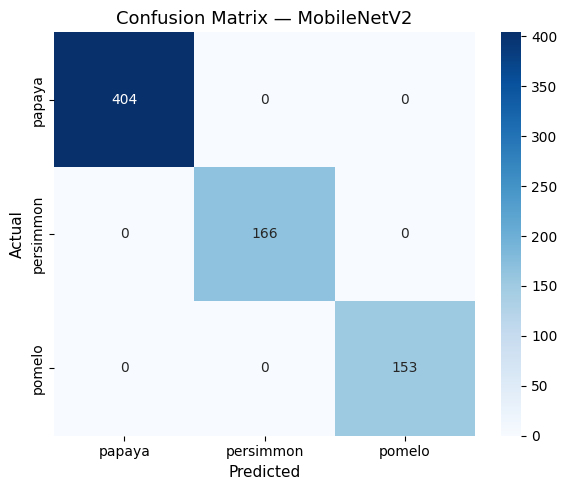

In [ ]:
def evaluate_model(model, test_gen, name, img_size):
    test_gen.reset()
    loss, acc = model.evaluate(test_gen, verbose=0)
    print(f'\n=== {name} | Test Loss: {loss:.4f} | Test Accuracy: {acc*100:.2f}% ===')

    test_gen.reset()
    y_pred_prob = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = test_gen.classes

    cm = confusion_matrix(y_true, y_pred)
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=13)
    plt.tight_layout()
    fname = name.lower().replace(' ', '_')
    plt.savefig(f'report/fig4_cm_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return acc

acc_cnn = evaluate_model(model_cnn, test_cnn, 'CNN Custom', IMG_SIZE_CNN)
acc_tl  = evaluate_model(model_tl,  test_tl,  'MobileNetV2', IMG_SIZE_TL)

In [ ]:
print('\n====== TỔNG KẾT SO SÁNH ======')
print(f'  CNN Custom   : {acc_cnn*100:.2f}%')
print(f'  MobileNetV2  : {acc_tl*100:.2f}%')
winner = 'MobileNetV2' if acc_tl >= acc_cnn else 'CNN Custom'
print(f'  Mô hình tốt hơn: {winner}')


====== TỔNG KẾT SO SÁNH ======
  CNN Custom   : 100.00%
  MobileNetV2  : 100.00%
  Mô hình tốt hơn: MobileNetV2


## Giai đoạn 6 — Demo dự đoán ảnh mới

In [ ]:
# Lưu model tốt nhất
best_model = model_tl if acc_tl >= acc_cnn else model_cnn
best_model.save('models/best_model.keras')
print('Đã lưu best_model.keras')

Đã lưu best_model.keras



Kết quả dự đoán: [Đu đủ] (99.7%)
  Đu đủ     :  99.7%  █████████████████████████████
  Bưởi      :   0.2%  
  Hồng      :   0.0%  


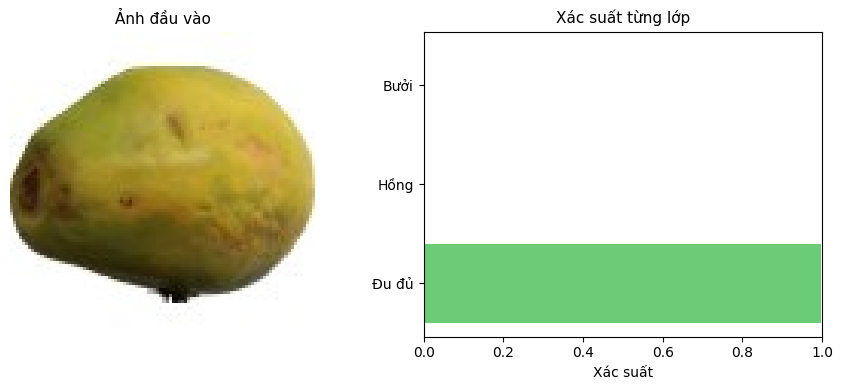

In [ ]:
# Hàm dự đoán ảnh đơn lẻ
def predict_image(img_path, model=None, img_size=(224, 224), use_mobilenet=True):
    if model is None:
        model = tf.keras.models.load_model('models/best_model.keras')

    img = Image.open(img_path).convert('RGB').resize(img_size)
    arr = np.array(img, dtype=np.float32)

    if use_mobilenet:
        arr = tf.keras.applications.mobilenet_v2.preprocess_input(arr)
    else:
        arr = arr / 255.0

    arr = np.expand_dims(arr, 0)
    probs = model.predict(arr, verbose=0)[0]

    label_vn = {'papaya': 'Đu đủ', 'persimmon': 'Hồng', 'pomelo': 'Bưởi'}
    results = sorted(zip(CLASSES, probs), key=lambda x: -x[1])

    print(f'\nKết quả dự đoán: [{label_vn[results[0][0]]}] ({results[0][1]*100:.1f}%)')
    for cls, prob in results:
        bar = '█' * int(prob * 30)
        print(f'  {label_vn[cls]:10s}: {prob*100:5.1f}%  {bar}')

    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
    ax[0].imshow(Image.open(img_path))
    ax[0].set_title(f'Ảnh đầu vào', fontsize=11)
    ax[0].axis('off')
    colors_bar = ['#6BCB77' if c == results[0][0] else '#AAAAAA' for c in CLASSES]
    ax[1].barh([label_vn[c] for c in CLASSES],
               [dict(zip(CLASSES, probs))[c] for c in CLASSES],
               color=colors_bar)
    ax[1].set_xlim(0, 1)
    ax[1].set_title('Xác suất từng lớp', fontsize=11)
    ax[1].set_xlabel('Xác suất')
    plt.tight_layout()
    plt.show()

# Thử trên 1 ảnh test ngẫu nhiên
sample_img = random.choice(list((DST_ROOT / 'test' / 'papaya').glob('*.jpg')))
predict_image(sample_img)

In [ ]:
# Giao diện Gradio (tuỳ chọn — ấn tượng khi demo)
import gradio as gr

_loaded_model = tf.keras.models.load_model('models/best_model.keras')
_use_mobilenet = (acc_tl >= acc_cnn)
_img_size = (224, 224) if _use_mobilenet else (128, 128)
LABEL_VN = {'papaya': 'Đu đủ', 'persimmon': 'Hồng', 'pomelo': 'Bưởi'}

def gradio_predict(pil_image):
    img = pil_image.convert('RGB').resize(_img_size)
    arr = np.array(img, dtype=np.float32)
    if _use_mobilenet:
        arr = tf.keras.applications.mobilenet_v2.preprocess_input(arr)
    else:
        arr = arr / 255.0
    probs = _loaded_model.predict(np.expand_dims(arr, 0), verbose=0)[0]
    return {LABEL_VN[c]: float(p) for c, p in zip(CLASSES, probs)}

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type='pil', label='Upload ảnh trái cây'),
    outputs=gr.Label(num_top_classes=3, label='Kết quả phân loại'),
    title='Phân loại Đu đủ / Hồng / Bưởi',
    description='Upload ảnh và nhận kết quả phân loại từ mô hình CNN/MobileNetV2'
)
demo.launch(share=True)  # share=True tạo link public 72h

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://776535c89804f30920.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Giai đoạn 7 — Checklist hoàn thiện báo cáo

| # | Hình/Số liệu | File | Đưa vào mục báo cáo |
|---|---|---|---|
| 1 | Biểu đồ phân phối dữ liệu | `report/fig1_data_distribution.png` | Mục 4 – Dữ liệu |
| 2 | Lưới ảnh mẫu 3 lớp | `report/fig2_sample_images.png` | Mục 4 – Dữ liệu |
| 3 | Đồ thị Accuracy/Loss cả 2 model | `report/fig3_training_curves.png` | Mục 7 – Kết quả |
| 4 | Confusion Matrix CNN | `report/fig4_cm_cnn_custom.png` | Mục 7 – Kết quả |
| 5 | Confusion Matrix MobileNetV2 | `report/fig4_cm_mobilenetv2.png` | Mục 7 – Kết quả |
| 6 | Test accuracy cả 2 model | (in ra console) | Mục 7 – Bảng so sánh |
| 7 | Ảnh demo Gradio (chụp màn hình) | thủ công | Mục 8 – Demo |

**Lưu ý quan trọng cho báo cáo:**
- Fruits-360 có nền trắng đồng nhất → accuracy cao (>95%) nhưng **không phản ánh thực tế**
- Nếu test thêm ảnh tự chụp → accuracy sẽ thấp hơn → giải thích lý do (domain shift)
- MobileNetV2 nhanh hơn và chính xác hơn vì tận dụng trọng số ImageNet (1.2M ảnh thực)
- CNN tự xây bị hạn chế bởi kích thước dataset nhỏ